# 네이버 쇼핑 결혼답례품 1페이지 쇼핑몰 리뷰 분석

In [100]:
import pandas as pd
from konlpy.tag import Okt
# CSV 파일을 읽어옵니다.
reviews = pd.read_csv('all_reviews.csv')

# Okt 객체를 초기화합니다.
okt = Okt()

In [101]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12371 entries, 0 to 12370
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  12369 non-null  object
dtypes: object(1)
memory usage: 96.8+ KB


In [102]:
reviews = reviews.dropna()

In [103]:
review_texts = reviews['Review']

# 각 리뷰에 대해 형태소 분석을 수행하고, 결과를 하나의 리스트로 합칩니다.
all_words = []

# okt()로 형태소 분석
for review in review_texts:
    morphs = okt.morphs(review, stem=True)
    all_words.extend(morphs)

In [104]:
all_words

['크기',
 '는',
 '작',
 '지만',
 '포장',
 'ㆍ',
 '구성',
 '이',
 '고급',
 '지다',
 '받다',
 '분',
 '들',
 '이',
 '넘다',
 '좋아하다',
 '기분',
 '이',
 '좋다',
 '쇼핑',
 '백',
 '이',
 '왜',
 '비싸다',
 '가하다',
 '튼튼하다',
 '좋다',
 '거여',
 '서',
 '선택',
 '하다',
 '잘',
 '하다',
 '같다',
 '답례',
 '품',
 '으로',
 '아주',
 '성공',
 '적',
 '이다',
 '배송',
 '도',
 '잘',
 '해주다',
 '꼼꼼하다',
 '검수',
 '부탁드리다',
 '불량하다',
 '개도',
 '없다',
 '만족하다',
 '스티커',
 '문구',
 '제작',
 '서비스',
 '넘다',
 '정말',
 '받다',
 '자다',
 '모르다',
 '너무',
 '예쁘다',
 '답례',
 '품',
 '으로',
 '하다',
 '좋다',
 '추천',
 '하다',
 '배',
 '송전',
 '에',
 '이',
 '것',
 '저',
 '것',
 '고민',
 '하고',
 '문의',
 '도',
 '많이',
 '하다',
 '친절하다',
 '다',
 '답변',
 '해주다',
 '배송',
 '도',
 '하루',
 '만에',
 '오다',
 '진짜',
 '만족하다',
 '가족',
 '식사',
 '자리',
 '답례',
 '품',
 '으로',
 '사용',
 '하다',
 '미리',
 '주문',
 '하다',
 '포장',
 '도',
 '꼼꼼하다',
 '디자인',
 '도',
 '이쁘다',
 '상담',
 '도',
 '친절하다',
 '해주다',
 '다음',
 '에',
 '또',
 '주문',
 '하다',
 '쇼핑',
 '백추',
 '가',
 '너무',
 '잘',
 '하다',
 '같다',
 '감사하다',
 '이',
 '사',
 '가면',
 '서',
 '공',
 '사',
 '소음',
 '으로',
 '고생',
 '하다',
 '이웃',
 '분들',
 '께',
 '돌리다',
 '사다',
 '판매'

### 불용어 제거

In [105]:
# Stopwords 파일 경로
file_path = '/Users/kang_hiee/Documents/GitHub/ubion/python/최종프로젝트/키워드분석/stopwords.txt'

# 파일을 cp949 인코딩으로 읽기
with open(file_path, 'r', encoding='cp949') as file:
    stopwords = file.read().split(',')

add_stopwords = ['는','다','이','가','더','잘','은','안','ㅎ','맛','거','개','서','만','한','고',
                 '걸','게','곳','중','라','분','수','전','못','두','ㅠ','날','굿','면','해',
                 '꼭','인','씩','번','점','시','말','내','듯']
stopwords.extend(add_stopwords)
# 리뷰 텍스트에서 불용어 제거 함수
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

# 리스트 형태의 all_words에서 불용어 제거 수행
cleaned_reviews = [remove_stopwords(text) for text in all_words]

# 결과 출력
cleaned_reviews


['크기',
 '',
 '작',
 '',
 '포장',
 'ㆍ',
 '구성',
 '',
 '고급',
 '지다',
 '',
 '',
 '',
 '',
 '',
 '좋아하다',
 '기분',
 '',
 '좋다',
 '쇼핑',
 '백',
 '',
 '',
 '비싸다',
 '가하다',
 '튼튼하다',
 '좋다',
 '거여',
 '',
 '선택',
 '',
 '',
 '',
 '',
 '답례',
 '품',
 '',
 '아주',
 '성공',
 '적',
 '',
 '배송',
 '도',
 '',
 '해주다',
 '꼼꼼하다',
 '검수',
 '부탁드리다',
 '불량하다',
 '개도',
 '',
 '만족하다',
 '스티커',
 '문구',
 '제작',
 '서비스',
 '',
 '',
 '',
 '자다',
 '',
 '',
 '예쁘다',
 '답례',
 '품',
 '',
 '',
 '좋다',
 '추천',
 '',
 '배',
 '송전',
 '',
 '',
 '',
 '',
 '',
 '고민',
 '',
 '문의',
 '도',
 '',
 '',
 '친절하다',
 '',
 '답변',
 '해주다',
 '배송',
 '도',
 '하루',
 '만에',
 '',
 '',
 '만족하다',
 '가족',
 '식사',
 '자리',
 '답례',
 '품',
 '',
 '사용',
 '',
 '미리',
 '주문',
 '',
 '포장',
 '도',
 '꼼꼼하다',
 '디자인',
 '도',
 '이쁘다',
 '상담',
 '도',
 '친절하다',
 '해주다',
 '',
 '',
 '',
 '주문',
 '',
 '쇼핑',
 '백추',
 '',
 '',
 '',
 '',
 '',
 '감사하다',
 '',
 '',
 '가면',
 '',
 '공',
 '',
 '소음',
 '',
 '고생',
 '',
 '이웃',
 '분들',
 '께',
 '돌리다',
 '사다',
 '판매',
 '',
 '님',
 '',
 '빠르다',
 '보내다',
 '자다',
 '전달',
 '',
 '',
 '',
 '쇼핑',
 '백',
 '',
 '',
 '판매

### cleaned_reviews가 ''인 항목이 있어서 제거 후 cleaned_reviews2로 저장

In [106]:
cleaned_reviews2 = [item for item in cleaned_reviews if item !='']
cleaned_reviews2

['크기',
 '작',
 '포장',
 'ㆍ',
 '구성',
 '고급',
 '지다',
 '좋아하다',
 '기분',
 '좋다',
 '쇼핑',
 '백',
 '비싸다',
 '가하다',
 '튼튼하다',
 '좋다',
 '거여',
 '선택',
 '답례',
 '품',
 '아주',
 '성공',
 '적',
 '배송',
 '도',
 '해주다',
 '꼼꼼하다',
 '검수',
 '부탁드리다',
 '불량하다',
 '개도',
 '만족하다',
 '스티커',
 '문구',
 '제작',
 '서비스',
 '자다',
 '예쁘다',
 '답례',
 '품',
 '좋다',
 '추천',
 '배',
 '송전',
 '고민',
 '문의',
 '도',
 '친절하다',
 '답변',
 '해주다',
 '배송',
 '도',
 '하루',
 '만에',
 '만족하다',
 '가족',
 '식사',
 '자리',
 '답례',
 '품',
 '사용',
 '미리',
 '주문',
 '포장',
 '도',
 '꼼꼼하다',
 '디자인',
 '도',
 '이쁘다',
 '상담',
 '도',
 '친절하다',
 '해주다',
 '주문',
 '쇼핑',
 '백추',
 '감사하다',
 '가면',
 '공',
 '소음',
 '고생',
 '이웃',
 '분들',
 '께',
 '돌리다',
 '사다',
 '판매',
 '님',
 '빠르다',
 '보내다',
 '자다',
 '전달',
 '쇼핑',
 '백',
 '판매',
 '다이소',
 '어울리다',
 '따로',
 '구매',
 '찌',
 '돌잔치',
 '자다',
 '인원',
 '안해',
 '50',
 '맞추다',
 '봉투',
 '오신',
 '분들',
 '드리다',
 '몇개',
 '안남다',
 '넉넉하다',
 '주문',
 '자다',
 '깨지다',
 '확인',
 '집',
 '배송',
 '포장',
 '도',
 '꼼꼼하다',
 '깨지다',
 '자다',
 '행사',
 '장',
 '행사',
 '자다',
 '치르다',
 '답례',
 '품다',
 '자다',
 '드리다',
 '마치다',
 '답례',
 '품',
 '고급스럽다',
 '만족하다',


### wordcloud 시각화

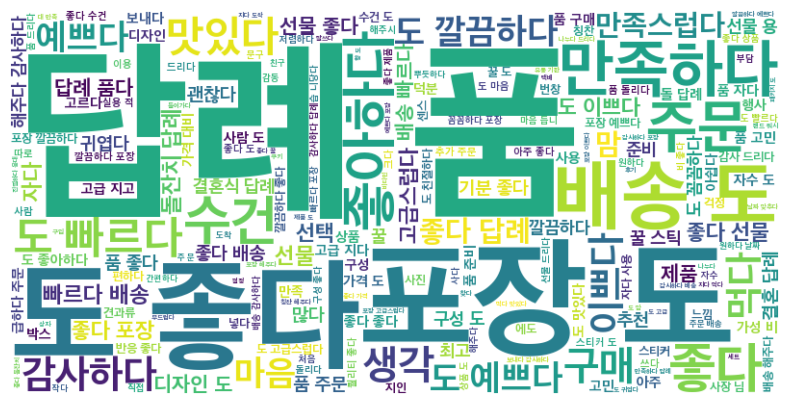

In [107]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt
# 형태소 리스트를 텍스트로 변환
text = ' '.join(cleaned_reviews2)

# WordCloud 객체 생성
wordcloud = WordCloud(font_path='/content/AppleSDGothicNeoB.ttf',  # 필요 시 폰트 경로 설정
                      width=800,
                      height=400,
                      background_color='white').generate(text)

# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 제거
plt.show()


In [109]:
from collections import Counter
# 워드클라우드에서 단어와 빈도수 추출
word_freq = wordcloud.process_text(text)
word_freq_counter = Counter(word_freq)

#단어 추출
total_words = word_freq_counter.most_common()

#데이터프레임으로 변환
df_top_words = pd.DataFrame(total_words, columns=['Word', 'Frequency'])

# 결과 출력
print(df_top_words)

# csv저장
df_top_words.to_csv('review_frequecy.csv', index=False)


        Word  Frequency
0       답례 품       3980
1       포장 도       1287
2       도 좋다       1128
3       배송 도       1049
4       만족하다        928
...      ...        ...
7726  답례 돌잔치          1
7727  답례 빠르다          1
7728   답례 먹다          1
7729  답례 해주다          1
7730  감사하다 품          1

[7731 rows x 2 columns]
